# Noise Effect on Waste Classification Using Image Processing

## Idea
This experiment investigates how image noise affects waste classification performance using the TrashNet dataset. Since real-world images may contain noise caused by poor lighting, low camera quality, or environmental conditions, artificial noise is added to the images to simulate real-world degradation.

The experiment compares three cases:

1. Original images
2. Noisy images
3. Noisy images after Gaussian filtering

The purpose is to evaluate whether noise reduces classification accuracy and whether Gaussian filtering can improve performance by smoothing noisy images before classification.

## Expected Outcome
The noisy images are expected to reduce model accuracy because noise can hide important visual features. Gaussian filtering is expected to improve the noisy image results by reducing noise while preserving the general shape of waste objects.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

2026-05-31 17:20:45.745007: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:20:45.933678: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:20:46.541519: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 17:20:49.540173: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = os.path.join(path, "dataset-resized")

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


In [3]:
# ============================================================
# 3. IMAGE SIZE AND BATCH SIZE
# ============================================================

img_size = (224, 224)
batch_size = 32

In [4]:
# ============================================================
# 4. ADD GAUSSIAN NOISE FUNCTION
# ============================================================

def add_gaussian_noise(img, mean=0, std=25):
    img = img.astype(np.float32)

    noise = np.random.normal(mean, std, img.shape)
    noisy_img = img + noise

    noisy_img = np.clip(noisy_img, 0, 255)
    noisy_img = noisy_img.astype(np.uint8)

    return noisy_img

In [5]:
# ============================================================
# 5. PREPROCESSING FUNCTIONS
# ============================================================

def original_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))
    img = preprocess_input(img.astype(np.float32))
    return img


def noisy_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Add Gaussian noise
    noisy_img = add_gaussian_noise(img, mean=0, std=25)

    noisy_img = preprocess_input(noisy_img.astype(np.float32))
    return noisy_img


def noisy_gaussian_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Add Gaussian noise
    noisy_img = add_gaussian_noise(img, mean=0, std=25)

    # Apply Gaussian filter to reduce noise
    filtered_img = cv2.GaussianBlur(noisy_img, (3, 3), 0)

    filtered_img = preprocess_input(filtered_img.astype(np.float32))
    return filtered_img

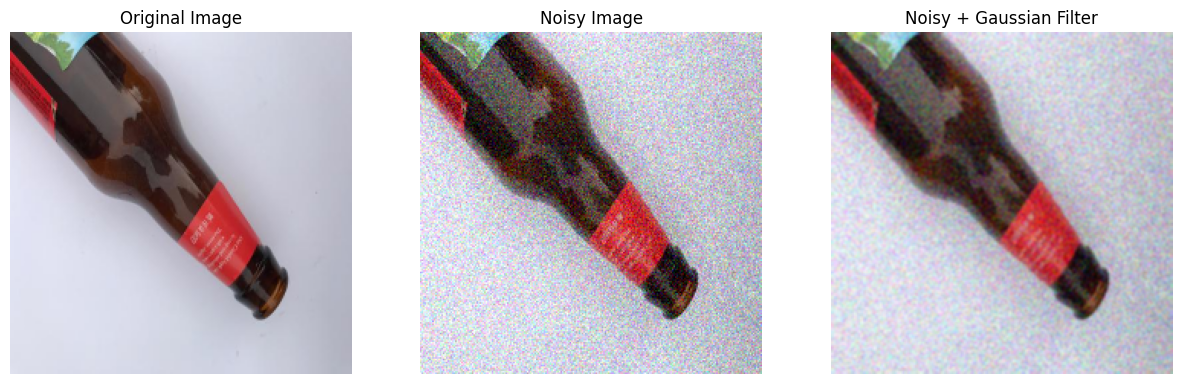

In [6]:
# ============================================================
# 6. VISUALIZE ORIGINAL, NOISY, AND FILTERED IMAGES
# ============================================================

classes = os.listdir(dataset_dir)
sample_class = classes[0]

sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

noisy_img = add_gaussian_noise(img, mean=0, std=25)
filtered_img = cv2.GaussianBlur(noisy_img, (3, 3), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_img)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filtered_img)
plt.title("Noisy + Gaussian Filter")
plt.axis("off")

plt.show()

In [7]:
# ============================================================
# 7. CREATE DATA GENERATORS
# ============================================================

original_datagen = ImageDataGenerator(
    preprocessing_function=original_preprocess,
    validation_split=0.2
)

noisy_datagen = ImageDataGenerator(
    preprocessing_function=noisy_preprocess,
    validation_split=0.2
)

noisy_gaussian_datagen = ImageDataGenerator(
    preprocessing_function=noisy_gaussian_preprocess,
    validation_split=0.2
)

In [8]:
# Original data
original_train = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

original_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [9]:
# Noisy data
noisy_train = noisy_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

noisy_val = noisy_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [10]:
# Noisy + Gaussian data
noisy_gaussian_train = noisy_gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

noisy_gaussian_val = noisy_gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [11]:
# ============================================================
# 8. BUILD MobileNetV2 MODEL
# ============================================================

def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
# ============================================================
# 9. TRAIN ORIGINAL MODEL
# ============================================================

original_model = build_model()

original_history = original_model.fit(
    original_train,
    validation_data=original_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 920ms/step - accuracy: 0.6774 - loss: 0.9036 - val_accuracy: 0.7296 - val_loss: 0.6805
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 860ms/step - accuracy: 0.8271 - loss: 0.4856 - val_accuracy: 0.7753 - val_loss: 0.6113
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 818ms/step - accuracy: 0.8646 - loss: 0.3459 - val_accuracy: 0.7833 - val_loss: 0.6263
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 871ms/step - accuracy: 0.8962 - loss: 0.2864 - val_accuracy: 0.7575 - val_loss: 0.6308
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 821ms/step - accuracy: 0.9170 - loss: 0.2265 - val_accuracy: 0.7714 - val_loss: 0.6473
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 842ms/step - accuracy: 0.9368 - loss: 0.1813 - val_accuracy: 0.7614 - val_loss: 0.6846
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.9457 - loss: 0.1569 - val_accuracy: 0.7296 - val_loss: 0.8097
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.9427 - loss: 0.1509 - val_accu

In [ ]:
# ============================================================
# 10. TRAIN NOISY MODEL
# ============================================================

noisy_model = build_model()

noisy_history = noisy_model.fit(
    noisy_train,
    validation_data=noisy_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 879ms/step - accuracy: 0.5242 - loss: 1.2553 - val_accuracy: 0.6064 - val_loss: 1.0392
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 873ms/step - accuracy: 0.6996 - loss: 0.8446 - val_accuracy: 0.6461 - val_loss: 0.9970
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 806ms/step - accuracy: 0.7312 - loss: 0.7195 - val_accuracy: 0.6978 - val_loss: 0.9093
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 884ms/step - accuracy: 0.7727 - loss: 0.6026 - val_accuracy: 0.6044 - val_loss: 1.1904
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 833ms/step - accuracy: 0.7752 - loss: 0.6064 - val_accuracy: 0.6779 - val_loss: 0.9588
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.8188 - loss: 0.5058

In [ ]:
# ============================================================
# 11. TRAIN NOISY + GAUSSIAN MODEL
# ============================================================

noisy_gaussian_model = build_model()

noisy_gaussian_history = noisy_gaussian_model.fit(
    noisy_gaussian_train,
    validation_data=noisy_gaussian_val,
    epochs=10
)

In [ ]:
# ============================================================
# 12. COMPARE RESULTS
# ============================================================

original_acc = original_history.history["val_accuracy"][-1]
noisy_acc = noisy_history.history["val_accuracy"][-1]
noisy_gaussian_acc = noisy_gaussian_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Noisy Images Validation Accuracy:", noisy_acc)
print("Noisy + Gaussian Filter Validation Accuracy:", noisy_gaussian_acc)

print("\nNoise Effect:", noisy_acc - original_acc)
print("Gaussian Recovery Effect:", noisy_gaussian_acc - noisy_acc)

In [ ]:
# ============================================================
# 13. PLOT RESULTS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(original_history.history["val_accuracy"], label="Original")
plt.plot(noisy_history.history["val_accuracy"], label="Noisy")
plt.plot(noisy_gaussian_history.history["val_accuracy"], label="Noisy + Gaussian")

plt.title("Effect of Noise and Gaussian Filtering on Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
methods = ["Original", "Noisy", "Noisy + Gaussian"]
accuracies = [original_acc, noisy_acc, noisy_gaussian_acc]

plt.figure(figsize=(8, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()